# QCQI Daily Playground

**Doel:** een wendbare **math & Python playground** voor je dagelijkse uur uit het boek: 
- lineaire-algebra helpers (kets, tensorproducten, partiele trace, metingen);
- Bloch-vector en visualisatie;
- Bell/CHSH-experimenteerhokje;
- Qiskit-sandboxes: teleportatie, superdense coding, Grover, Kraus-kanalen, 3-qubit bit-flip code.

> Tip: werk in blokken van ~25 minuten (pomodoro). Begin met **Unit I** (toestanden, metingen) en schuif daarna door naar Unit II (algoritmen).

## Sessie-doelen (vul in / vink af)
- [ ] Vandaag 1 concept kiezen (bv. Bell-paren, CHSH of Grover).
- [ ] Een kleine demo runnen en 1 variatie proberen.
- [ ] Kernnotities (2–3 bullets) aan het eind van de sessie.

In [1]:
# Setup & versies (lokale omgeving): 
# Als Qiskit lokaal niet aanwezig is, installeer dan eerst (alleen op je eigen machine):
# !pip install -U "qiskit>=2.0" "qiskit-aer"
import sys, platform
print("Python:", sys.version.split()[0], "| Platform:", platform.platform())

try:
    import numpy as np
    print("NumPy:", np.__version__)
except Exception as e:
    print("NumPy niet beschikbaar:", e)

try:
    import matplotlib
    import matplotlib.pyplot as plt
    print("Matplotlib:", matplotlib.__version__)
except Exception as e:
    print("Matplotlib niet beschikbaar:", e)

# Qiskit (optioneel in deze omgeving)
try:
    import qiskit
    from qiskit import QuantumCircuit
    from qiskit.primitives import Sampler, Estimator
    print("Qiskit:", qiskit.__version__)
    try:
        from qiskit_aer import AerSimulator
        print("Qiskit AER: beschikbaar")
    except Exception as e:
        print("Qiskit AER niet beschikbaar:", e)
except Exception as e:
    print("Qiskit niet beschikbaar in deze omgeving:", e)

Python: 3.12.3 | Platform: Linux-5.15.167.4-microsoft-standard-WSL2-x86_64-with-glibc2.39
NumPy: 1.26.4
Matplotlib: 3.9.0
Qiskit: 1.4.3
Qiskit AER: beschikbaar


## Lineaire-algebra helpers

In [2]:
import numpy as np
from functools import reduce

# Basis-kets en Paulimatrices
ket0 = np.array([1,0], dtype=complex)
ket1 = np.array([0,1], dtype=complex)

I = np.eye(2, dtype=complex)
X = np.array([[0,1],[1,0]], dtype=complex)
Y = np.array([[0,-1j],[1j,0]], dtype=complex)
Z = np.array([[1,0],[0,-1]], dtype=complex)
H = (1/np.sqrt(2))*np.array([[1,1],[1,-1]], dtype=complex)
S = np.array([[1,0],[0,1j]], dtype=complex)
T = np.array([[1,0],[0,np.exp(1j*np.pi/4)]], dtype=complex)

def kron(*ops):
    # Kronecker product van meerdere operatoren (links->rechts).
    return reduce(np.kron, ops)

def normalize(state):
    nrm = np.linalg.norm(state)
    return state if nrm == 0 else state/nrm

def to_density(state):
    # |psi><psi|
    state = normalize(state)
    return np.outer(state, np.conjugate(state))

def probs_z(state, n_qubits):
    # Meetkansen in de Z-basis voor een pure statevector.
    state = normalize(state)
    p = np.abs(state)**2
    return {format(i, f"0{n_qubits}b"): float(p[i]) for i in range(len(state))}

def single_qubit_expand(U, target, n_qubits):
    # Embed een 1-qubit gate U op 'target' in een n-qubit ruimte.
    # Conventie: qubit 0 is de least significant (Qiskit-conventie).
    ops = []
    for q in range(n_qubits):
        ops.append(U if q == target else I)
    return kron(*reversed(ops))  # reversed want numpy-kron links=MSB

def apply_gate(state, U_op):
    return U_op @ state

def basis_state(bitstring):
    # Maak |bitstring> (bv. '010').
    n = len(bitstring)
    idx = int(bitstring, 2)
    vec = np.zeros(2**n, dtype=complex)
    vec[idx] = 1.0
    return vec

def projector(bitstring):
    v = basis_state(bitstring)
    return np.outer(v, np.conjugate(v))

def partial_trace(rho, keep, dims=None):
    # Partiele trace over alle subsystemen behalve 'keep' (tuple van indices).
    # dims: lijst met lokale dimensies (default: allemaal 2).
    # Retourneert gereduceerde dichtheidsmatrix.
    if dims is None:
        n = int(np.log2(rho.shape[0]))
        dims = [2]*n
    subsystems = list(range(len(dims)))
    throw = [i for i in subsystems if i not in keep]
    res = rho.copy()
    for t in sorted(throw):
        d = dims[-1 - t]  # vanwege MSB/LSB volgorde in kron
        res = res.reshape(d, -1, d, -1).trace(axis1=0, axis2=2)
    return res

## Bloch-vector & visualisatie (1 qubit of gereduceerde state)

In [3]:
import numpy as np

def bloch_vector_from_rho(rho1):
    # Bloch-vector ( <X>,<Y>,<Z> ) uit 1-qubit dichtheidsmatrix.
    return np.array([np.real(np.trace(rho1 @ X)),
                     np.real(np.trace(rho1 @ Y)),
                     np.real(np.trace(rho1 @ Z))])

def reduced_rho(rho, qubit, n_qubits):
    # Gereduceerde 1-qubit rho voor 'qubit' (0=LSB).
    return partial_trace(rho, keep=(qubit,), dims=[2]*n_qubits)

def plot_bloch(vec):
    # Eenvoudige Bloch-plot (geen stijlen/kleuren gespecificeerd).
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Unit-sfeer wireframe
    u = np.linspace(0, 2*np.pi, 40)
    v = np.linspace(0, np.pi, 20)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(x, y, z, linewidth=0.3)

    # Vector
    ax.quiver(0,0,0, vec[0], vec[1], vec[2], length=1, normalize=False)

    ax.set_xlim([-1,1]); ax.set_ylim([-1,1]); ax.set_zlim([-1,1])
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title('Bloch vector')
    plt.show()

# Demo: |+> op de Bloch-sfeer
psi_plus = normalize((ket0 + ket1)/np.sqrt(2))
rho_plus = to_density(psi_plus)
vec = bloch_vector_from_rho(rho_plus)
print("Bloch <X,Y,Z> voor |+>:", vec)
# plot_bloch(vec)   # ontgrendel om te plotten

Bloch <X,Y,Z> voor |+>: [1. 0. 0.]


## Bell-paren en CHSH-waarde

In [4]:
def bell_state(which="phi+"):
    # Retourneer 2-qubit Bell statevector.
    if which == "phi+":
        return normalize((kron(ket0,ket0) + kron(ket1,ket1))/np.sqrt(2))
    if which == "phi-":
        return normalize((kron(ket0,ket0) - kron(ket1,ket1))/np.sqrt(2))
    if which == "psi+":
        return normalize((kron(ket0,ket1) + kron(ket1,ket0))/np.sqrt(2))
    if which == "psi-":
        return normalize((kron(ket0,ket1) - kron(ket1,ket0))/np.sqrt(2))
    raise ValueError("which in {'phi+','phi-','psi+','psi-'}")

def obs_equator(theta):
    # 1-qubit observable in X–Z vlak: cos(theta) Z + sin(theta) X.
    return np.cos(theta)*Z + np.sin(theta)*X

def chsh_value(state, a0, a1, b0, b1):
    # <CHSH> = <A0⊗(B0+B1) + A1⊗(B0−B1)> met equator-observabelen.
    A0, A1 = obs_equator(a0), obs_equator(a1)
    B0, B1 = obs_equator(b0), obs_equator(b1)
    CHSH = kron(A0, B0+B1) + kron(A1, B0-B1)
    rho = to_density(state)
    return np.real(np.trace(CHSH @ rho))

# Demo (maximale schending sqrt(8) ~ 2.828 voor |phi+> met juiste hoeken)
psi = bell_state("phi+")
a0, a1 = 0.0, np.pi/2   # Z en X
b0, b1 = np.pi/4, -np.pi/4
print("CHSH(|phi+>):", chsh_value(psi, a0, a1, b0, b1))

CHSH(|phi+>): 2.8284271247461907


## Qiskit sandbox — Teleportatie

/tmp/ipykernel_56052/3779535506.py:25: DeprecationWarning: The method ``qiskit.circuit.instructionset.InstructionSet.c_if()`` is deprecated as of qiskit 1.3.0. It will be removed in 2.0.0.
  qc.x(2).c_if(qc.cregs[0], 1)   # als bit1==1, X
/tmp/ipykernel_56052/3779535506.py:26: DeprecationWarning: The method ``qiskit.circuit.instructionset.InstructionSet.c_if()`` is deprecated as of qiskit 1.3.0. It will be removed in 2.0.0.
  qc.z(2).c_if(qc.cregs[0], 2)   # als bit0==1, Z


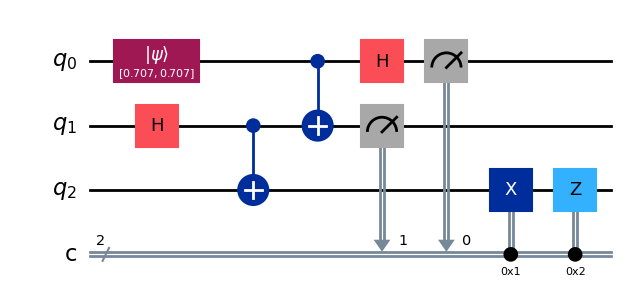

In [5]:
try:
    from qiskit import QuantumCircuit, ClassicalRegister
    from qiskit.primitives import Sampler
    from qiskit_aer import AerSimulator
    import numpy as np

    def teleportation_circuit(alpha=1/np.sqrt(2), beta=1/np.sqrt(2)):
        # Teleportatie van |psi>=alpha|0>+beta|1> van qubit 0 naar qubit 2.
        qc = QuantumCircuit(3,2)
        try:
            qc.initialize([alpha, beta], 0)
        except Exception:
            # Fallback: prepare approx state via rotations (voor real alpha,beta)
            theta = 2*np.arccos(alpha.real)
            qc.ry(theta, 0)

        # Bell-paar tussen qubit 1 en 2
        qc.h(1); qc.cx(1,2)

        # Bell-meting op (0,1)
        qc.cx(0,1); qc.h(0)
        qc.measure(0,0); qc.measure(1,1)

        # Correcties op qubit 2
        qc.x(2).c_if(qc.cregs[0], 1)   # als bit1==1, X
        qc.z(2).c_if(qc.cregs[0], 2)   # als bit0==1, Z
        return qc

    qc_tel = teleportation_circuit()
    display(qc_tel.draw(output="mpl"))
    # sampler = Sampler()
    # result = sampler.run([qc_tel], shots=4096).result()
    # print(result.quasi_dists[0])

except Exception as e:
    print("Qiskit/AER niet beschikbaar in deze omgeving; maak lokaal een run:", e)

## Qiskit sandbox — Superdense coding

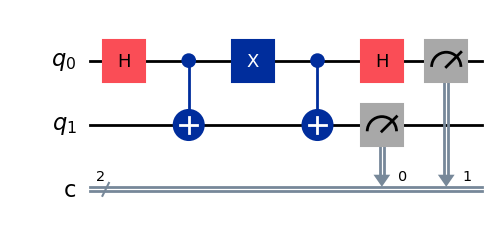

In [6]:
try:
    from qiskit import QuantumCircuit

    def superdense_coding(c=1, d=0):
        # Encode klassieke bits (c,d) in 1 qubit met verstrengeling.
        qc = QuantumCircuit(2,2)
        qc.h(0); qc.cx(0,1)   # maak |Phi+>
        # Alice encodeert Z^d X^c op qubit 0
        if d: qc.z(0)
        if c: qc.x(0)
        # Bob decodeert
        qc.cx(0,1); qc.h(0)
        qc.measure([0,1],[1,0])
        return qc

    qc_sd = superdense_coding(c=1, d=0)
    display(qc_sd.draw(output="mpl"))
except Exception as e:
    print("Qiskit niet beschikbaar:", e)

## Qiskit sandbox — Grover (klein voorbeeld)

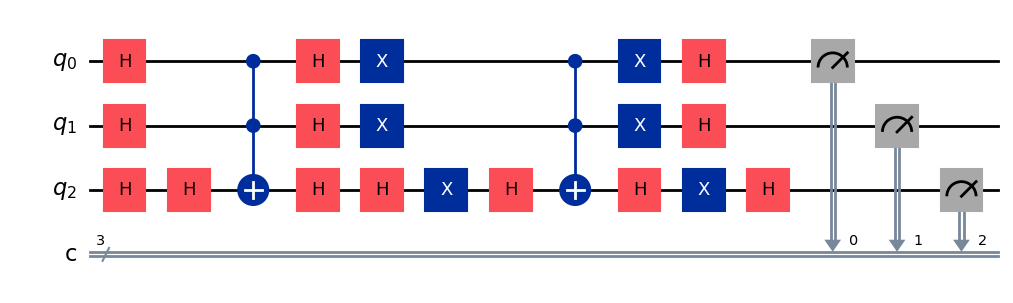

In [7]:
try:
    from qiskit import QuantumCircuit
    from qiskit_aer import AerSimulator
    from qiskit.primitives import Sampler

    def mcz(qc, ctrls, target):
        # Multi-controlled Z via H-MCX-H.
        qc.h(target)
        qc.mcx(ctrls, target)
        qc.h(target)

    def mark_bitstring(n, bitstring):
        # Oracle die |x> markeert als x == bitstring door een Z-fase.
        bs = bitstring
        qc = QuantumCircuit(n)
        # Breng naar |11..1> op doel dmv X
        for i, b in enumerate(reversed(bs)):  # qubit 0 = LSB
            if b == '0':
                qc.x(i)
        mcz(qc, list(range(n-1)), n-1)  # target = MSB index in deze bouw
        for i, b in enumerate(reversed(bs)):
            if b == '0':
                qc.x(i)
        return qc

    def diffuser(n):
        qc = QuantumCircuit(n)
        for q in range(n): qc.h(q); qc.x(q)
        mcz(qc, list(range(n-1)), n-1)
        for q in range(n): qc.x(q); qc.h(q)
        return qc

    def grover_demo(n=3, marked="111", iters=1):
        qc = QuantumCircuit(n, n)
        for q in range(n): qc.h(q)
        oracle = mark_bitstring(n, marked)
        diff = diffuser(n)
        for _ in range(iters):
            qc.compose(oracle, inplace=True)
            qc.compose(diff, inplace=True)
        qc.measure(range(n), range(n))
        return qc

    qc_g = grover_demo(n=3, marked="111", iters=1)
    display(qc_g.draw(output="mpl"))
    # sampler = Sampler()
    # print(sampler.run([qc_g], shots=2048).result().quasi_dists[0])

except Exception as e:
    print("Qiskit/AER niet beschikbaar:", e)

## Qiskit sandbox — Kraus-kanaal (dephasing)

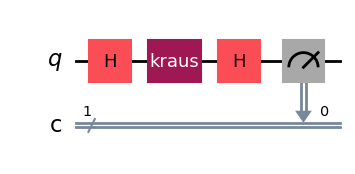

In [8]:
try:
    from qiskit.quantum_info import Kraus
    from qiskit import QuantumCircuit
    import numpy as np

    def dephasing_instruction(p=0.2):
        K0 = np.sqrt(1-p) * np.eye(2)
        K1 = np.sqrt(p)   * np.array([[1,0],[0,-1]])
        return Kraus([K0, K1]).to_instruction()

    qc = QuantumCircuit(1,1)
    qc.h(0)
    qc.append(dephasing_instruction(0.3), [0])
    qc.h(0)
    qc.measure(0,0)
    display(qc.draw(output="mpl"))
except Exception as e:
    print("Qiskit niet beschikbaar:", e)

## Qiskit sandbox — 3-qubit bit-flip code (encode -> fout -> syndroom -> correctie)

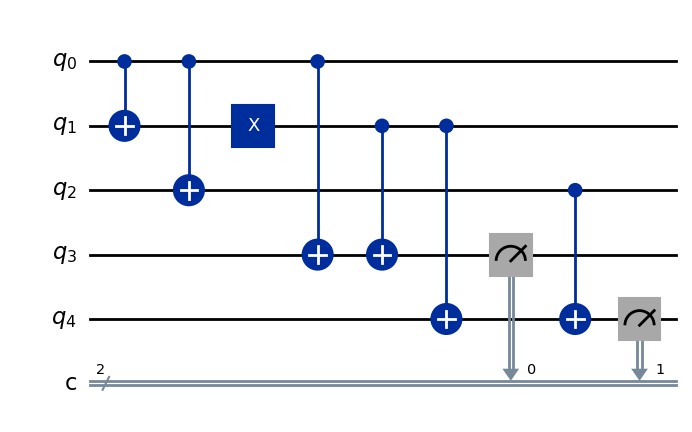

In [9]:
try:
    from qiskit import QuantumCircuit, ClassicalRegister

    def bitflip_encode():
        qc = QuantumCircuit(5,2) # data:0..2, ancilla:3..4, klassiek:2 bits voor syndroom
        # Encode |psi> op qubit 0 -> |psi psi psi> via CNOTs
        qc.cx(0,1); qc.cx(0,2)
        return qc

    def bitflip_syndrome_and_correct():
        qc = QuantumCircuit(5,2)
        # Syndroom meten met stabilizers ZZI (ancilla 3) en IZZ (ancilla 4)
        qc.cx(0,3); qc.cx(1,3)   # meet Z⊗Z op (0,1)
        qc.cx(1,4); qc.cx(2,4)   # meet Z⊗Z op (1,2)
        qc.measure(3,0); qc.measure(4,1)
        # Correcties (klassiek afhankelijk) schets:
        # (00): geen fout; (10): fout op qubit 0; (11): fout op qubit 1; (01): fout op qubit 2
        return qc

    qc = QuantumCircuit(5,2)
    qc.compose(bitflip_encode(), inplace=True)
    # Invoeg een X-fout demo op qubit 1
    qc.x(1)
    qc.compose(bitflip_syndrome_and_correct(), inplace=True)
    display(qc.draw(output="mpl"))
except Exception as e:
    print("Qiskit niet beschikbaar:", e)

## Playground — probeer iets nu meteen

In [10]:
# 1) CHSH op |phi+> met standaardhoeken
psi = bell_state("phi+")
print("CHSH default:", chsh_value(psi, 0.0, np.pi/2, np.pi/4, -np.pi/4))

# 2) Meetkansen van |+++> in Z-basis
state = normalize(kron( (ket0+ket1)/np.sqrt(2), (ket0+ket1)/np.sqrt(2), (ket0+ket1)/np.sqrt(2) ))
print("P_Z(|+++>):", probs_z(state, 3))

CHSH default: 2.8284271247461907
P_Z(|+++>): {'000': 0.12500000000000003, '001': 0.12500000000000003, '010': 0.12500000000000003, '011': 0.12500000000000003, '100': 0.12500000000000003, '101': 0.12500000000000003, '110': 0.12500000000000003, '111': 0.12500000000000003}


## Notities (vandaag)

> Schrijf hier 2–3 bullets met wat je vandaag begrepen/geoefend hebt.